In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load data
df = pd.read_excel('data.xlsx')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [6]:
# Data Cleaning (improved & complete)
df = df.dropna(subset=['CustomerID'])                    # Remove missing CustomerID
df = df[df['Quantity'] > 0]                              # Remove cancelled orders
df = df[~df['StockCode'].str.contains('POST|C2|M|DOT|BANK', na=False)]  # Remove non-product codes
df = df.drop_duplicates()

In [9]:
# RFM Calculation
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'UnitPrice': lambda x: (x * df.loc[x.index, 'Quantity']).sum()  # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [14]:
# Recency Score (higher score = more recent → better)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=range(5, 0, -1))

# Frequency & Monetary Score - Use rank method (this fixes the error)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=range(1, 6))
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=range(1, 6))

# Convert to integer
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Final RFM Score (out of 555)
rfm['RFM_Score'] = rfm['R_Score'] * 100 + rfm['F_Score'] * 10 + rfm['M_Score']

print(rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head())

   CustomerID  R_Score  F_Score  M_Score  RFM_Score
0     12346.0        1        1        5        115
1     12347.0        5        5        5        555
2     12348.0        2        4        4        244
3     12349.0        4        1        4        414
4     12350.0        1        1        2        112


In [19]:
# Customer Segments
def segment_customers(df):
    if df['RFM_Score'] >= 444:           # Top tier
        return 'High Value'
    elif df['RFM_Score'] >= 344:         # Good tier
        return 'Loyal'
    elif df['RFM_Score'] >= 244:         # Warning tier
        return 'At-Risk'
    else:
        return 'Dormant'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

In [20]:
# Save cleaned file for Power BI
rfm.to_excel('RFM_Cleaned_for_PowerBI.xlsx', index=False)
print("✅ RFM analysis completed and file saved!")

✅ RFM analysis completed and file saved!


C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_12664\3167238848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', palette='viridis')


Segment
Dormant       1555
High Value    1284
At-Risk        766
Loyal          729
Name: count, dtype: int64


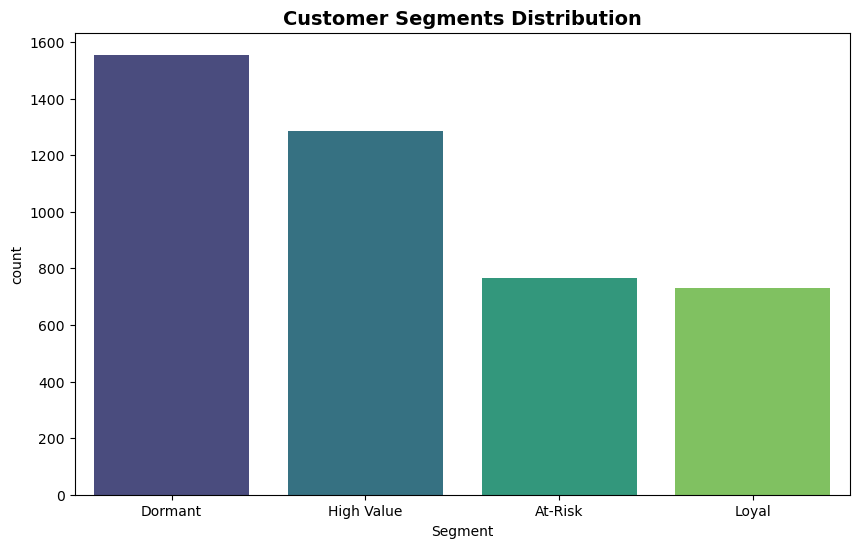

In [21]:
# Visualizations 
plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x='Segment', palette='viridis')
plt.title('Customer Segments Distribution', fontsize=14, fontweight='bold')
plt.savefig('Customer_Segments.png', dpi=300)

print(rfm['Segment'].value_counts())